In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
import random

import geopandas as gpd
from matplotlib import pyplot as plt 
import numpy as np
import shapely
from shapely.plotting import plot_polygon
import rasterio
import torch

from src.construct_dataset.assign_tile_and_tilegroup import create_tiles


try:
    RANDOM_SEED = int(os.environ["RANDOM_SEED"])
except:
    RANDOM_SEED = 42

from PIL import ImageColor


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
N_GROUPS = 5
parent_rng = np.random.default_rng(seed=RANDOM_SEED)
def get_new_random_seed():
    return parent_rng.integers(0,2**32)


In [2]:
tilegroup_colors = [
    "#E69F00",  
    "#f0e442",  
    "#009E73",  
    "#2771b2",  
    "#CC79A7",  
]

gdf = gpd.read_file("yep.geojson")

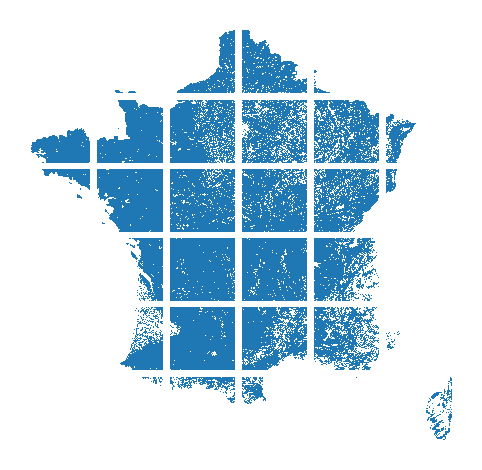

In [3]:
_,ax = plt.subplots()
ax.set_axis_off()
plt.tight_layout()
gdf[gdf["tilegroup"]!=-1].plot(ax=ax)

plt.show()

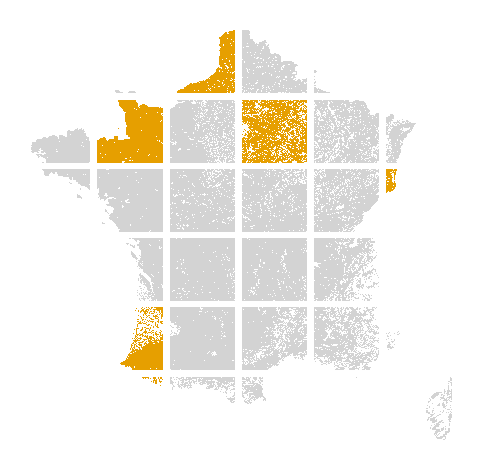

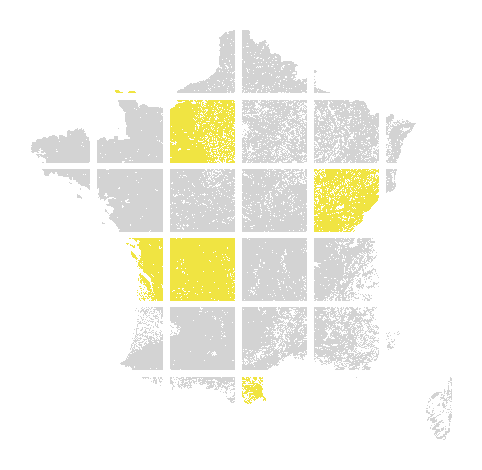

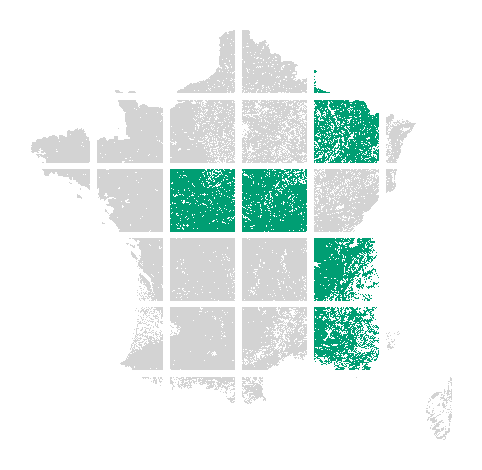

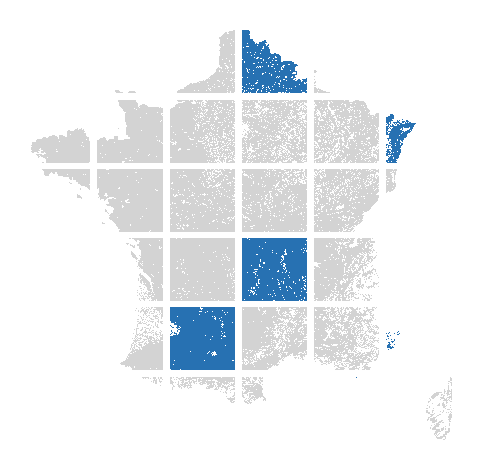

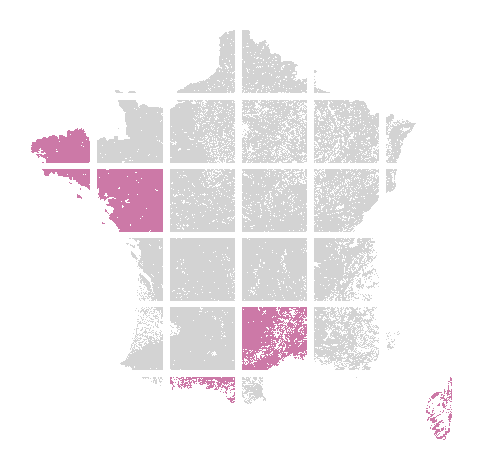

In [4]:
curr_gdf = gdf[gdf["tilegroup"]!=-1]

for i in range(N_GROUPS):
    col = tilegroup_colors[i]
    _,ax = plt.subplots()
    ax.set_axis_off()
    plt.tight_layout()
    
    point_color = [
        col if tg == i else "#D3D3D3" for tg in curr_gdf["tilegroup"]
    ]
    curr_gdf.plot(ax=ax,color=point_color)
    plt.show()

In [ ]:
curr_gdf = gdf[(gdf["thz_class"].str.contains("Subtropics")) | (gdf["thz_class"].str.contains("Temperate"))]

_,ax = plt.subplots()
ax.set_axis_off()
plt.tight_layout()
colors = ["#2771b2" if ("Temperate" in s) else "#E69F00" for s in curr_gdf["thz_class"]]

curr_gdf.plot(ax=ax, color=colors)
plt.show()

<Axes: >

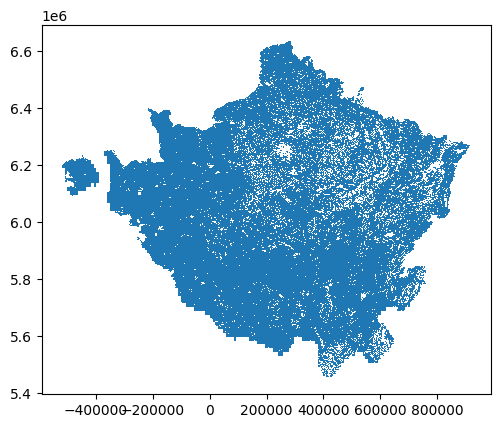

In [13]:
curr_gdf = gdf[gdf["thz_class"].str.contains("Temperate")]
curr_gdf.plot()